### **Import Dataset AG News**

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

ds = load_dataset("wangrongsheng/ag_news")

print(ds["train"][0])
print(ds["test"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}
{'text': "Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.", 'label': 2}


In [ ]:
import pandas as pd

# Convert ke DataFrame
train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["test"])

# Menampilkan 5 data pertama
display(train_df.head())
display(test_df.head())

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


,text,label
0,Fears for T N pension after talks Unions repre...,2
1,The Race is On: Second Private Team Sets Launc...,3
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3


In [ ]:
# Melihat jumlah data
print(len(ds["train"]))
print(len(ds["test"]))

120000
7600


In [ ]:
# Melihat fitur/kolom
print(ds["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}


In [ ]:
from collections import Counter

# Melihat statistik label
print(Counter(ds["train"]["label"]))
print(Counter(ds["test"]["label"]))

Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})
Counter({2: 1900, 3: 1900, 1: 1900, 0: 1900})


### **Preprocessing**

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Case Folding
    text = text.lower()

    # 2. Data Cleaning
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenization:
    tokens = word_tokenize(text)

    # 4. Stopword Removal
    cleaned_tokens = [w for w in tokens if w not in stop_words]

    return " ".join(cleaned_tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
import nltk

nltk.download('punkt_tab')

train_df_clean = train_df.sample(20000, random_state=42).copy()
test_df_clean = test_df.copy()

train_df_clean['clean_text'] = train_df_clean['text'].apply(preprocess_text)
test_df_clean['clean_text'] = test_df_clean['text'].apply(preprocess_text)

display(train_df_clean[['text', 'clean_text']].head())
display(test_df_clean[['text', 'clean_text']].head())

print("Preprocessing Selesai!")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,clean_text
71787,"BBC set for major shake-up, claims newspaper L...",bbc set major shakeup claims newspaper london ...
67218,Marsh averts cash crunch Embattled insurance b...,marsh averts cash crunch embattled insurance b...
54066,"Jeter, Yankees Look to Take Control (AP) AP - ...",jeter yankees look take control ap ap derek je...
7168,Flying the Sun to Safety When the Genesis caps...,flying sun safety genesis capsule comes back e...
29618,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,stocks seen flat nortel oil weigh new york reu...


,text,clean_text
0,Fears for T N pension after talks Unions repre...,fears n pension talks unions representing work...
1,The Race is On: Second Private Team Sets Launc...,race second private team sets launch date huma...
2,Ky. Company Wins Grant to Study Peptides (AP) ...,ky company wins grant study peptides ap ap com...
3,Prediction Unit Helps Forecast Wildfires (AP) ...,prediction unit helps forecast wildfires ap ap...
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,calif aims limit farmrelated smog ap ap southe...


Preprocessing Selesai!


### **TF-IDF Representation**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2             # OPTIONAL
)

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df_clean['clean_text'])

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(test_df_clean['clean_text'])

print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)

Shape of X_train_tfidf: (20000, 10000)
Shape of X_test_tfidf: (7600, 10000)


### **Training Model**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Define target variables for training and testing
y_train = train_df_clean['label']
y_test = test_df_clean['label']

# Initialize the Multinomial Naive Bayes model
naive_bayes_model = MultinomialNB()

# Train the model using the TF-IDF features and the training labels
naive_bayes_model.fit(X_train_tfidf, y_train)

print("Naive Bayes Model Trained Successfully!")

Naive Bayes Model Trained Successfully!


### **Prediction Model**

In [ ]:
# Make predictions on the test set
y_pred = naive_bayes_model.predict(X_test_tfidf)

print("Prediksi pertama dari model Naive Bayes:")
print(y_pred[:10]) # Menampilkan 10 hasil prediksi pertama

Prediksi pertama dari model Naive Bayes:
[2 3 3 1 3 3 3 3 3 3]


### **Evaluation Model**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions on the test set (assuming y_pred is already calculated)
# y_pred = naive_bayes_model.predict(X_test_tfidf) # Uncomment if y_pred is not yet available

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8917
Precision: 0.8912
Recall: 0.8917
F1-Score: 0.8912

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1900
           1       0.94      0.98      0.96      1900
           2       0.87      0.83      0.85      1900
           3       0.85      0.87      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600




=== Confusion Matrix ===
[[1690   69   90   51]
 [  22 1857    8   13]
 [  75   24 1582  219]
 [  75   32  145 1648]]


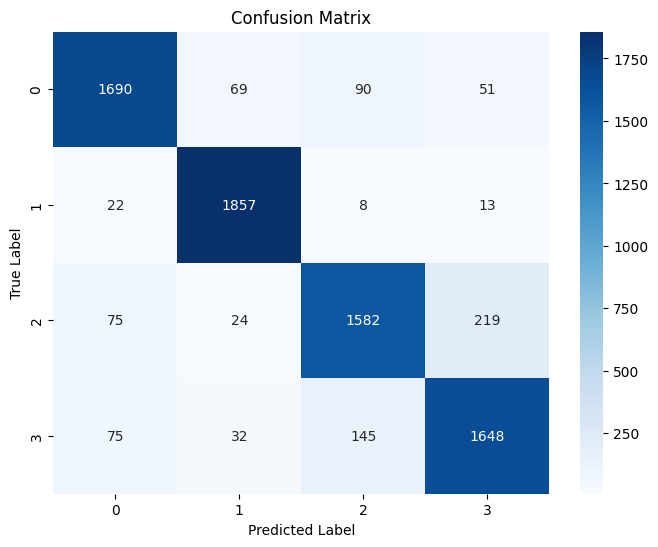

In [ ]:
# Visualize the Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=naive_bayes_model.classes_,
            yticklabels=naive_bayes_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

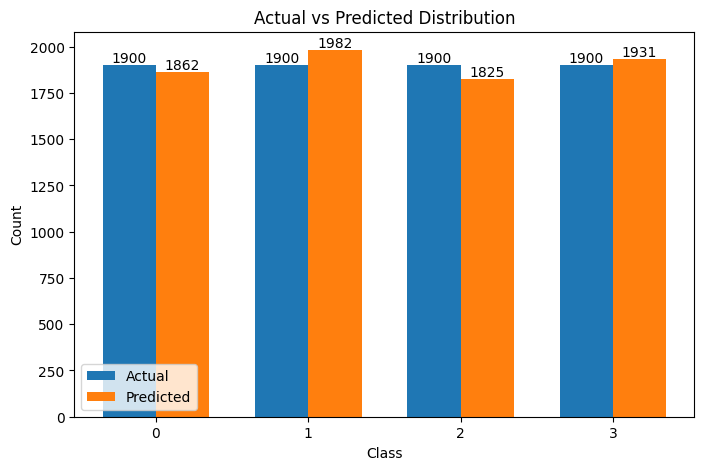

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Membuat DataFrame untuk membandingkan data aktual dan prediksi

df_compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

actual_counts = df_compare['Actual'].value_counts().sort_index()
pred_counts = df_compare['Predicted'].value_counts().sort_index()

x = np.arange(len(actual_counts))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, actual_counts, width, label='Actual')
bars2 = plt.bar(x + width/2, pred_counts, width, label='Predicted')

# 👉 TAMBAH ANGKA
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 int(height),
                 ha='center',
                 va='bottom')

plt.title("Actual vs Predicted Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(x, ['0','1','2','3'])
plt.legend()

plt.show()

### **Ekspor Model**

In [ ]:
import joblib
import os

print("=== Proses Ekspor Model Naive Bayes ===")

# Membuat direktori khusus untuk menyimpan model (opsional agar rapi)
os.makedirs("saved_models", exist_ok=True)

# 1. Menentukan nama file penyimpanan
path_model = "saved_models/naive_bayes_agnews.pkl"
path_vectorizer = "saved_models/tfidf_vectorizer_nb.pkl"

# 2. Menyimpan Model Multinomial Naive Bayes
joblib.dump(naive_bayes_model, path_model)
print(f"Model Naive Bayes berhasil disimpan di: {path_model}")

# 3. Menyimpan TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, path_vectorizer)
print(f"TF-IDF Vectorizer berhasil disimpan di: {path_vectorizer}")

=== Proses Ekspor Model Naive Bayes ===
Model Naive Bayes berhasil disimpan di: saved_models/naive_bayes_agnews.pkl
TF-IDF Vectorizer berhasil disimpan di: saved_models/tfidf_vectorizer_nb.pkl
